In [566]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt


runfile = 'time_analysis_2_hour'

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4



MAX_Q15 = 32767 / 32768


In [515]:


# RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
# dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
# dev.base.load_bitfile()
# dev.set_register('event_logger', 'reset', 1, raw=True)
# time.sleep(0.1)
# dev.set_register('event_logger', 'reset', 0, raw=True)

# # Signal chain
# dev.set_all_registers(
#     "iir1",
#     compute_coeff.highpass_1st(1e4, Ts=16e-9),
#     reset=True,
# )

# for idx in range(9):
#     dev.set_register("fir9", f"h{idx}", 0.109375)

# # Do not use raw=True for normalized Q15 values.
# dev.set_register("peak_detector", "trig_level", 0.008)
# dev.set_register("peak_detector", "invert_input", 0)
# dev.set_register("peak_detector", "n_integration", 300)
# dev.set_register("peak_detector", "dead_time", 300)
# # Histogram
# dev.set_register("histogram", "offset", -0.007165694774164504)
# dev.set_register("histogram", "gain", 0.08361136196556104)
# dev.set_register("histogram", "pulse_width", 1024)

# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)
# dev.set_register("histogram", "counting_enable", 1,)

# # Configure before arming.
# log = EventLogger(dev)
# log.configure(
#     band_low=0.0,
#     band_high=MAX_Q15,
#     flush_ms=100,
# )
# print(dev.get_register("peak_detector", "dead_time", raw=True))

# n = log.run(duration=3600, output_dir=runfile)



In [516]:

# print("drained events:", n)
# print("FPGA events:",
#       dev.get_register("event_logger", "events_lo"))
# print("dropped:", log.dropped())
raw = load_run(f"{runfile}/events_*.bin")
ts_us, energy, chb = unpack(raw)

print(f"{len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s" if len(ts_us) > 1 else "no events")
a, b, ppm = fit_clock(f"{runfile}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix = counter_to_unix(ts_us, a, b)

9446834 events, span 7077.6 s
Crystal drift: +2.4 ppm


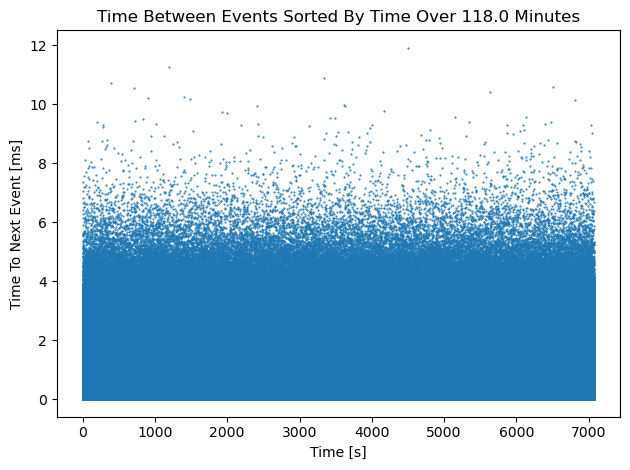

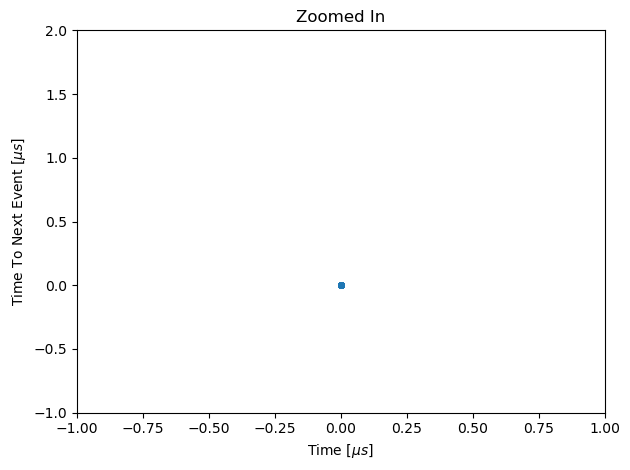

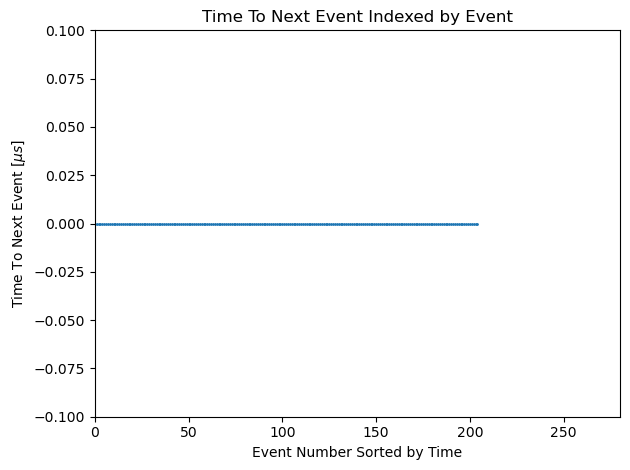

In [544]:

plt.plot(ts_us[1:]/1e6, (ts_us[1:]-ts_us[:-1])/1e3, '.', markersize=1)
plt.xlabel(f"Time [s]")
plt.ylabel(f"Time To Next Event [ms]")
plt.title(f"Time Between Events Sorted By Time Over {(ts_us[-1]-ts_us[0])/6e7:.1f} Minutes")
plt.tight_layout()
# plt.savefig('Time.png', transparent=True, bbox_inches='tight')


plt.show()

plt.plot(ts_us[1:], (ts_us[1:]-ts_us[:-1]), '.', markersize=8)
plt.ylim(-1, 2)
plt.xlim(-1, 1)
plt.xlabel(f"Time [$\mu s$]")
plt.title(f'Zoomed In')
plt.ylabel(f"Time To Next Event [$\mu s$]")
plt.tight_layout()
# plt.savefig('Zoom.png', transparent=True, bbox_inches='tight')

plt.show()
plt.plot(range(len(ts_us[1:])), (ts_us[1:]-ts_us[:-1]), '.', markersize=2)
plt.ylim(-0.1, 0.1)
plt.xlim(0, 280)
plt.xlabel(f"Event Number Sorted by Time")
plt.title(f'Time To Next Event Indexed by Event')
plt.ylabel(f"Time To Next Event [$\mu s$]")
plt.tight_layout()
# plt.savefig('Event_index.png', transparent=True, bbox_inches='tight')

plt.show()

In [518]:
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.optimize import curve_fit

# # 1. Compute time differences
# times_us = np.asarray(ts_us, dtype=np.int64)
# dt_us = np.diff(times_us)

# # 2. Histogram with bin centers
# bins = 500
# counts, bin_edges = np.histogram(dt_us, bins=bins)
# bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
# bin_width = bin_edges[1] - bin_edges[0]  # Calculate exact bin width (delta_b)

# # 3. Isolate valid region above dead time cutoff
# dead_time_us = 4.8
# mask = bin_centers > dead_time_us

# fit_x = bin_centers[mask]
# fit_y = counts[mask]
# N_valid = np.sum(fit_y)  # Total counts in the valid region above dead time


# # Normalized 1-parameter exponential model: N(dt) = N_valid * delta_b * lambda * exp(-lambda * (dt - t_dead))
# def exp_func(dt, lmbda):
#     return N_valid * bin_width * lmbda * np.exp(-lmbda * (dt - dead_time_us))


# # Fit the single parameter lambda
# popt, pcov = curve_fit(
#     exp_func,
#     fit_x,
#     fit_y,
#     p0=[0.001],
# )
# fit_lambda = popt[0]
# fit_lambda_err = np.sqrt(pcov[0, 0])  # 1x1 covariance matrix

# # 4. Plotting
# plt.figure(figsize=(9, 5.5))

# # Separate non-zero and zero bins across the entire histogram
# nonzero_mask = counts > 0
# zero_mask = counts == 0

# # Plot non-zero count bins
# plt.scatter(
#     bin_centers[nonzero_mask],
#     counts[nonzero_mask],
#     color="navy",
#     alpha=0.8,
#     s=35,
#     label="Measured Data (Counts > 0)",
# )

# # Plot zero-count bins explicitly on the log baseline (y = 0.3)
# baseline_zero_y = 0.3
# plt.scatter(
#     bin_centers[zero_mask],
#     np.full(np.sum(zero_mask), baseline_zero_y),
#     color="crimson",
#     marker="x",
#     s=45,
#     linewidth=1.5,
#     label="Zero-Count Bins (Counts = 0)",
# )

# # Plot exponential fit curve
# plt.plot(
#     fit_x,
#     exp_func(fit_x, *popt),
#     "g--",
#     linewidth=2,
#     label=f"lambda Poisson Fit ($\lambda$ = {fit_lambda:.4f})",
# )

# # Dead time threshold vertical line
# plt.axvline(
#     dead_time_us,
#     color="black",
#     linestyle=":",
#     alpha=0.7,
#     label=f"Dead Time Limit ({dead_time_us} $\mu s$)",
# )

# plt.yscale("log")
# plt.ylim(bottom=0.2)  # Ensures the y = 0.3 baseline markers are visible
# plt.xlabel(r"$\Delta t$ ($\mu s$)")
# plt.ylabel("Counts")
# plt.title(r"Interval Distribution of $\beta$-Decay Events (Including $N=0$ Bins)")
# plt.legend()
# plt.grid(True, which="both", linestyle=":", alpha=0.5)
# plt.show()

# # 5. Chi-Square calculation including ALL bins above dead time
# N_obs = fit_y  # Includes zero-count bins
# N_fit = exp_func(fit_x, *popt)

# # Pearson's Chi-Square: uses expected value in denominator
# chi2 = np.sum((N_obs - N_fit) ** 2 / N_fit)
# num_params = 1  # Fitting only lambda
# dof = len(N_obs) - num_params
# chi2_red = chi2 / dof

# print(f"Total bins above dead time: {len(N_obs)}")
# print(f"Zero-count bins included in chi2: {np.sum(N_obs == 0)}")
# print(f"Chi-Square (chi2): {chi2:.2f}")
# print(f"Degrees of Freedom (dof): {dof}")
# print(f"Reduced Chi-Square (chi2_red): {chi2_red:.2f}")


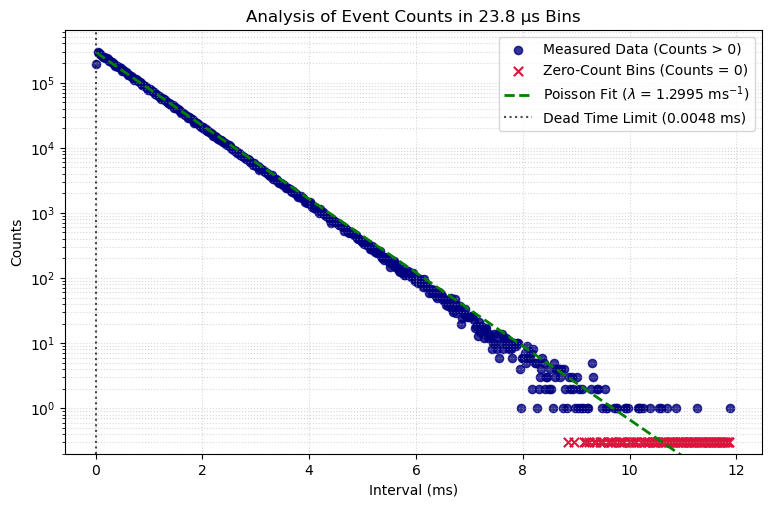

In [764]:

# 1. Compute time differences in milliseconds
times_ms = np.asarray(ts_us, dtype=np.int64) / 1e3  # Converted to ms
dt_ms = np.diff(times_ms)

# 2. Histogram with bin centers
bins = 500
counts, bin_edges = np.histogram(dt_ms, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]  # Bin width in ms

# 3. Isolate valid region above dead time cutoff (4.8 us = 0.0048 ms)
dead_time_ms = 4.8 / 1e3
mask = bin_centers > dead_time_ms

fit_x = bin_centers[mask]
fit_y = counts[mask]
N_valid = np.sum(fit_y)  # Total counts in the valid region


# Normalized 1-parameter exponential model
def exp_func(dt, lmbda):
    return N_valid * bin_width * lmbda * np.exp(-lmbda * (dt - dead_time_ms))


# Fit the single parameter lambda (p0 adjusted for ms scale)
popt, pcov = curve_fit(
    exp_func,
    fit_x,
    fit_y,
    p0=[1.0],
)
fit_lambda = popt[0]  # in ms^-1
fit_lambda_err = np.sqrt(pcov[0, 0])

# 4. Plotting
plt.figure(figsize=(9, 5.5))

nonzero_mask = counts > 0
zero_mask = counts == 0

# Plot non-zero count bins
plt.scatter(
    bin_centers[nonzero_mask],
    counts[nonzero_mask],
    color="navy",
    alpha=0.8,
    s=35,
    label="Measured Data (Counts > 0)",
)

# Plot zero-count bins explicitly on the log baseline
baseline_zero_y = 0.3
plt.scatter(
    bin_centers[zero_mask],
    np.full(np.sum(zero_mask), baseline_zero_y),
    color="crimson",
    marker="x",
    s=45,
    linewidth=1.5,
    label="Zero-Count Bins (Counts = 0)",
)

# Plot exponential fit curve
plt.plot(
    fit_x,
    exp_func(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f} $\mathrm{{ms}}^{{-1}}$)",
)

# Dead time threshold vertical line
plt.axvline(
    dead_time_ms,
    color="black",
    linestyle=":",
    alpha=0.7,
    label=f"Dead Time Limit ({dead_time_ms:.4f} ms)",
)

plt.yscale("log")
plt.ylim(bottom=0.2)
plt.xlabel(r"Interval (ms)")  # Updated axis label
plt.ylabel("Counts")
plt.title(f"Analysis of Event Counts in {bin_width * 1e3:.1f} µs Bins")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
# print(f"Each interval chunk is {bin_width:.5f} ms ")

# plt.savefig('my_plot.png', transparent=True, bbox_inches='tight')

plt.show()


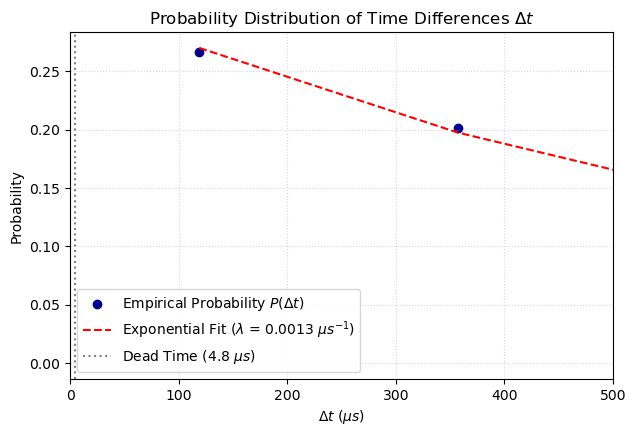

In [766]:

# 1. Compute time differences
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

# 2. Histogram counts & convert to empirical probabilities
counts, bin_edges = np.histogram(dt_us, bins=50)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
prob_dt = counts / np.sum(counts)  # Empirical probability per bin

# 3. Fit exponential probability above dead time threshold (4.8 us)
dead_time = 4.8
mask = bin_centers > dead_time

fit_x = bin_centers[mask]
fit_y = prob_dt[mask]


def exp_prob(dt, P0, lmbda):
    return P0 * np.exp(-lmbda * (dt - dead_time))


nonzero = fit_y > 0
popt, _ = curve_fit(
    exp_prob, fit_x[nonzero], fit_y[nonzero], p0=[fit_y[0], 0.001]
)

# Plot normalized probability
plt.figure(figsize=(7, 4.5))
plt.scatter(
    bin_centers,
    prob_dt,
    color="darkblue",
    label="Empirical Probability $P(\Delta t)$",
)
plt.plot(
    fit_x,
    exp_prob(fit_x, *popt),
    "r--",
    label=f"Exponential Fit ($\lambda$ = {popt[1]:.4f} $\mu s^{{-1}}$)",
)
plt.axvline(
    dead_time, color="gray", linestyle=":", label=f"Dead Time ({dead_time} $\mu s$)"
)
# plt.yscale("log")
plt.xlabel(r"$\Delta t$ ($\mu s$)")
plt.ylabel("Probability")
plt.title(r"Probability Distribution of Time Differences $\Delta t$")
plt.xlim(0,500)
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()


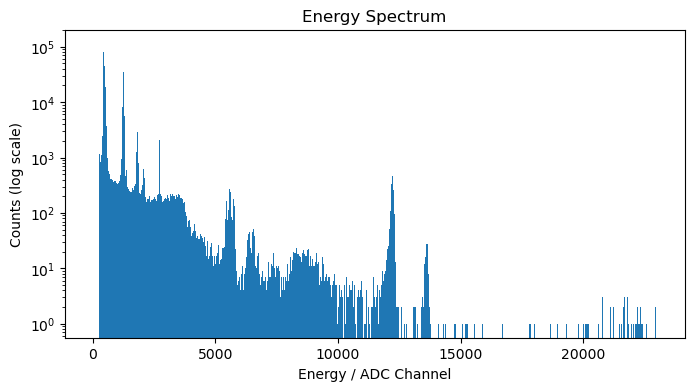

In [758]:


# # 1. Correct Plot for Raw Event Sequence
# plt.figure(figsize=(8, 4))
# plt.plot(energy, linewidth=0.5)
# plt.title("Pulse Height per Event")
# plt.xlabel("Event Index")
# plt.ylabel("Energy / ADC Channel")
# plt.show()

adu = range(max(energy)+1)
# 2. Correct Plot for True Energy Spectrum
plt.figure(figsize=(8, 4))
h = plt.hist(energy, bins=adu, log=True)
#plt.hist(energy, log=True)
plt.title("Energy Spectrum")
plt.xlabel("Energy / ADC Channel")
plt.ylabel("Counts (log scale)")
#plt.xlim(0, 14000)  # Set x-axis limits to show the full range of ADC channels
plt.show()




In [759]:
import numpy as np

# Your known calibration points
cal_adu = np.array([450, 1243, 12216])
cal_kev = np.array([6.395, 14.4129, 122.06])

# Calculate the quadratic fit (2nd-degree polynomial)
a, b, c = np.polyfit(cal_adu, cal_kev, deg=2)

print(f"a = {a:e}")
print(f"b = {b:e}")
print(f"c = {c:e}")


def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu




a = -2.555374e-08
b = 1.015411e-02
c = 1.830826e+00


In [760]:
h[1]

array([0.0000e+00, 1.0000e+00, 2.0000e+00, ..., 2.2985e+04, 2.2986e+04,
       2.2987e+04], shape=(22988,))

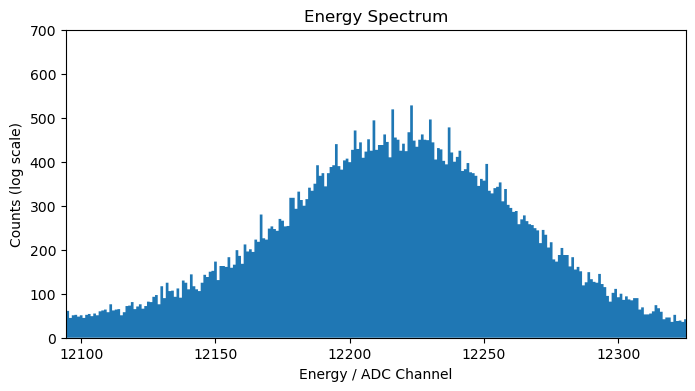

In [761]:
plt.figure(figsize=(8, 4))
plt.fill_between(adu[1:],h[0],step='mid')

plt.title("Energy Spectrum")
plt.xlabel("Energy / ADC Channel")
plt.ylabel("Counts (log scale)")
plt.ylim(0, 7e2)
plt.xlim(kev_to_adu(120.9), kev_to_adu(123.1))  # Set x-axis limits to show the full range of ADC channels
#plt.yscale('log')
plt.show()

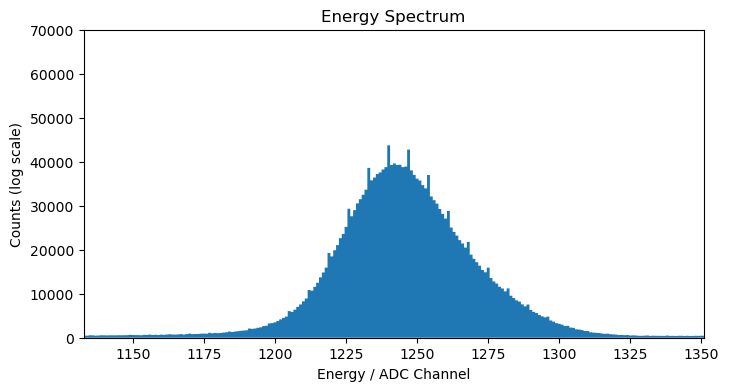

In [762]:
plt.figure(figsize=(8, 4))
plt.fill_between(adu[1:],h[0],step='mid')

plt.title("Energy Spectrum")
plt.xlabel("Energy / ADC Channel")
plt.ylabel("Counts (log scale)")

plt.ylim(0, 0.7e5)
plt.xlim(kev_to_adu(13.3), kev_to_adu(15.5))  # Set x-axis limits to show the full range of ADC channels
plt.show()

In [525]:
# interval_us = 100000  # 100 ms in microseconds
interval_us = 100000  # 100 ms in microseconds

Found 3326124 events in the 6.2 - 6.6 keV range.
Grouped into 70776 100.0-ms intervals.
Max events in a single 100.0-ms interval: 78
Variance/Mean Ratio: 1.020  (Ideal: ~1.0)
Chi-Squared (χ²): 62.360
Reduced Chi-Squared (χ²/dof): 1.094
Fitted Lambda (λ): 47.005
nonzero counts: 56


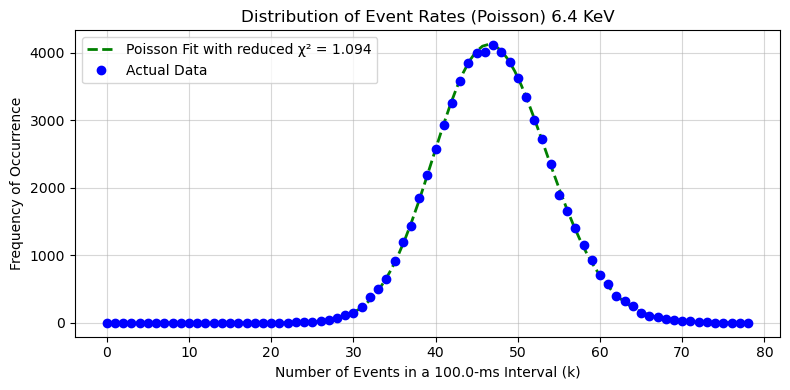

Found 2150390 events in the 13.3 - 15.5 keV range.
Grouped into 141553 50.0-ms intervals.
Max events in a single 50.0-ms interval: 35
Variance/Mean Ratio: 1.001  (Ideal: ~1.0)
Chi-Squared (χ²): 33.966
Reduced Chi-Squared (χ²/dof): 0.999
Fitted Lambda (λ): 15.183
nonzero counts: 36


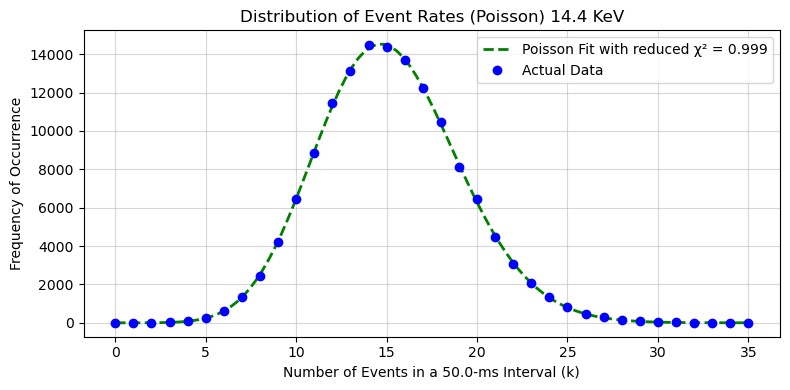

Found 3047 events in the 120 - 124 keV range.
Grouped into 337 21000.0-ms intervals.
Max events in a single 21000.0-ms interval: 20
Variance/Mean Ratio: 1.122  (Ideal: ~1.0)
Chi-Squared (χ²): 15.455
Reduced Chi-Squared (χ²/dof): 0.966
Fitted Lambda (λ): 8.739
nonzero counts: 18


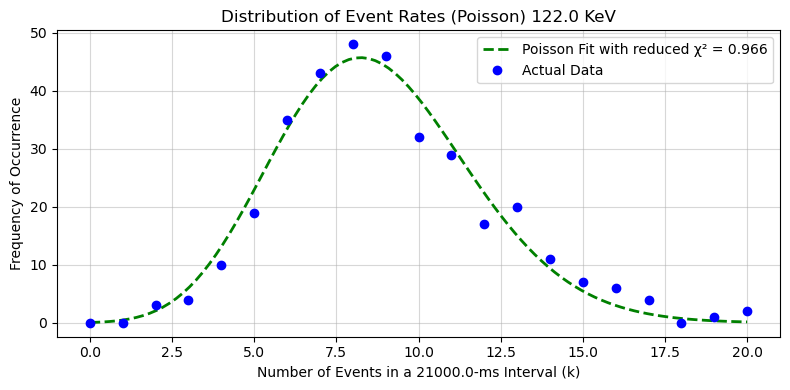

In [705]:
def graph_poissonian(e_start=14.2, e_end=14.6, bin=100000, save=False):
    energy_kev = adu_to_kev(energy)
    # --- Assuming `energy_kev` is now your array of energies in keV ---
    # For demonstration purposes, if your energy array is already in keV, use:

    # 2. Filter for the 14.2 - 14.6 keV range
    mask = (energy_kev >= e_start) & (energy_kev <= e_end)

    # Output Array 1 & 2: Filtered energies and their corresponding times
    filtered_energies = energy_kev[mask]
    filtered_times_us = ts_us[mask]

    if len(ts_us) > 0:

        start_time = ts_us[ts_us > 0][0]

        end_time = ts_us[-1]
        
        time_bins = np.arange(start_time, end_time + interval_us, bin) 
      
        frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
        # if auto_bin:
        #     frequencies, time_bins = np.histogram(filtered_times_us, bins="scott")
        interval_timestamps = time_bins[:-1] 
        
        print(f"Found {len(filtered_energies)} events in the {e_start} - {e_end} keV range.")
        print(f"Grouped into {len(frequencies)} {bin/(1e3)}-ms intervals.")
        print(f"Max events in a single {bin/(1e3)}-ms interval: {np.max(frequencies)}")

    else:
        print("No events to process.")
        filtered_energies = np.array([])
        filtered_times_us = np.array([])
        frequencies = np.array([])
        interval_timestamps = np.array([])

    max_count = int(np.max(frequencies))
    integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

    # Calculate histogram
    counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


    # mask = counts > 0
    # counts = counts[mask]
    # bin_centers = bin_centers[mask]




# # Replace your raw formula with SciPy's numerically stable PMF
#     def poisson_pmf(k, lmbda):
#         total_intervals = len(frequencies)
#         return total_intervals * poisson.pmf(k, lmbda)



    # 2. Define the true Poisson Probability Mass Function
    def poisson_pmf(k, lmbda):
        # Calculate probability and scale it by the total number of 1ms intervals
        total_intervals = len(frequencies)
        return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

    # 3. Perform the curve fit
    # A great initial guess (p0) for lambda is simply the mean of the raw data
    popt, pcov = curve_fit(
        poisson_pmf, 
        bin_centers, 
        counts, 
        p0=[np.mean(frequencies)]
    )
    fit_lambda = popt[0]

    fit_x = np.linspace(0, max_count, 100)
    # fit_x = np.arange(0, max_count + 1)  


    # 5. Plotting
    plt.figure(figsize=(8, 4))

    observed = counts
    expected = poisson_pmf(bin_centers, *popt)

    valid_bins = expected > 0.5
    obs = observed[valid_bins]
    exp = expected[valid_bins]
    sigma = np.sqrt(exp)

    chi_squared = np.sum(((obs - exp) / sigma) ** 2)

    n_params = len(popt)  # 1 parameter (lambda)
    dof = len(obs) - n_params

    # 5. Calculate Reduced Chi-Squared
    reduced_chi_squared = chi_squared / dof


    sample_mean = np.mean(frequencies)
    sample_var = np.var(frequencies)
    dispersion = sample_var / sample_mean

    # print(f"Sample Mean (λ): {sample_mean:.2f}")
    print(f"Variance/Mean Ratio: {dispersion:.3f}  (Ideal: ~1.0)")
    # print(f"Physical Event Rate: {event_rate:.2f} counts/sec")


    print(f"Chi-Squared (χ²): {chi_squared:.3f}")
    # print(f"Degrees of Freedom (dof): {dof}")
    print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")
    print(f"Fitted Lambda (λ): {fit_lambda:.3f}")
    print(f"nonzero counts: {len(counts[counts>0])}")

    plt.plot(
        fit_x,
        poisson_pmf(fit_x, *popt),
        "g--",
        linewidth=2,
        label=f"Poisson Fit with reduced χ² = {reduced_chi_squared:.3f}"
    )

    # Plot the actual data as points
    plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Actual Data')

    # Optional: log scale
    # plt.yscale('log')
    average_kev = np.average([e_end,e_start])
    plt.title(f"Distribution of Event Rates (Poisson) {average_kev:.1f} KeV")
    plt.xlabel(f"Number of Events in a {bin/(1e3)}-ms Interval (k)")
    plt.ylabel("Frequency of Occurrence")


    plt.legend()
    plt.grid(True, alpha=0.5)
    # plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
    plt.tight_layout()


    if save:
        # Define your desired output path
        base_path = Path(f"poisson_fit_{average_kev:.1f}.png")
        stem = base_path.stem  # "poisson_fit"
        suffix = base_path.suffix  # ".png"
        parent = base_path.parent  # Folder directory

        save_path = base_path
        counter = 1

        # Increment counter until a unique filename is found
        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")

    plt.show()
# s_val = 100000
# f_val = s_val/2.5
# t_val = s_val/100
# graph_poissonian(e_start=6.2, e_end=6.6, bin=s_val, save=False)
# graph_poissonian(e_start=14.2, e_end=14.6, bin=f_val, save=False)
# graph_poissonian(e_start=121.8, e_end=122.2, bin=t_val, save=False)
# s_val = 100000        # 14.4 keV: Bin open for 100 ms
# f_val = s_val / 2.5    # 6.5 keV:  Bin open for 40 ms (0.4x s_val)
# t_val = s_val * 2000     # 122 keV:  Bin open for 4,000 ms = 4 seconds (40x s_val)

graph_poissonian(e_start=6.2,  e_end=6.6,  bin=1e5)
graph_poissonian(e_start=13.3, e_end=15.5, bin=5e4)
graph_poissonian(e_start=120, e_end=124, bin=2.1e7)

Found 1304587 events in the 14.2 - 14.6 keV range.
Grouped into 70776 100-ms intervals.
Max events in a single 100-ms interval: 42
Chi-Squared (χ²): 75.056
Degrees of Freedom (dof): 36
Reduced Chi-Squared (χ²/dof): 2.085


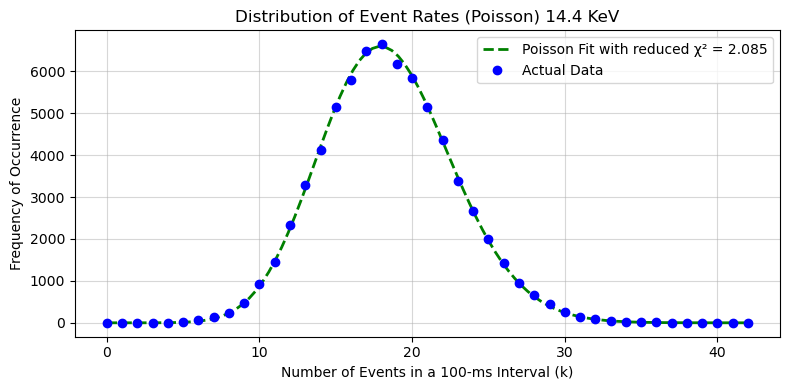

In [527]:

# 1. Convert ADU to keV
# Make sure your C1-C4 constants are defined, as well as gain and offset for your run.
energy_kev = adu_to_kev(energy)
# --- Assuming `energy_kev` is now your array of energies in keV ---
# For demonstration purposes, if your energy array is already in keV, use:

# 2. Filter for the 14.2 - 14.6 keV range
mask = (energy_kev >= 14.2) & (energy_kev <= 14.6)

# Output Array 1 & 2: Filtered energies and their corresponding times
filtered_energies = energy_kev[mask]
filtered_times_us = ts_us[mask]
# 3. Create 1 millisecond (1000 microseconds) bins

if len(ts_us) > 0:
    # We span the bins from the very beginning to the very end of the run

    # start_time = ts_us[0]
    start_time = ts_us[ts_us > 0][0]

    end_time = ts_us[-1]
    
    # Generate bin edges every 1000 us
    time_bins = np.arange(start_time, end_time + interval_us, interval_us)
    
    # Output Array 3: Calculate the frequency in each 1 ms interval
    # np.histogram counts how many 'filtered_times_us' fall into each bin
    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
    
    # (Optional) Get the corresponding timestamps for the frequencies (e.g., the start or center of the bin)
    interval_timestamps = time_bins[:-1] 
    
    print(f"Found {len(filtered_energies)} events in the 14.2 - 14.6 keV range.")
    print(f"Grouped into {len(frequencies)} 100-ms intervals.")
    print(f"Max events in a single 100-ms interval: {np.max(frequencies)}")

else:
    print("No events to process.")
    filtered_energies = np.array([])
    filtered_times_us = np.array([])
    frequencies = np.array([])
    interval_timestamps = np.array([])

#
# 1. Force integer bins (Poisson only works with discrete integers 0, 1, 2, 3...)
max_count = int(np.max(frequencies))
integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

# Calculate histogram
counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 2. Define the true Poisson Probability Mass Function
def poisson_pmf(k, lmbda):
    # Calculate probability and scale it by the total number of 1ms intervals
    total_intervals = len(frequencies)
    return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

# 3. Perform the curve fit
# A great initial guess (p0) for lambda is simply the mean of the raw data
popt, pcov = curve_fit(
    poisson_pmf, 
    bin_centers, 
    counts, 
    p0=[np.mean(frequencies)]
)
fit_lambda = popt[0]

# 4. Generate smooth X values for drawing the fit line
# (Using many points so the curve looks smooth)
fit_x = np.linspace(0, max_count, 100)

# 5. Plotting
plt.figure(figsize=(8, 4))

# Plot the fitted curve




observed = counts
expected = poisson_pmf(bin_centers, *popt)

valid_bins = expected > 0.5 
obs = observed[valid_bins]
exp = expected[valid_bins]
sigma = np.sqrt(exp)

chi_squared = np.sum(((obs - exp) / sigma) ** 2)

n_params = len(popt)  # 1 parameter (lambda)
dof = len(obs) - n_params

# 5. Calculate Reduced Chi-Squared
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared (χ²): {chi_squared:.3f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")

plt.plot(
    fit_x,
    poisson_pmf(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit with reduced χ² = {reduced_chi_squared:.3f}"
)

# Plot the actual data as points
plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Actual Data')

# Optional: log scale
# plt.yscale('log')

plt.title("Distribution of Event Rates (Poisson) 14.4 KeV")
plt.xlabel("Number of Events in a 100-ms Interval (k)")
plt.ylabel("Frequency of Occurrence")


plt.legend()
plt.grid(True, alpha=0.5)
# plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
plt.tight_layout()
plt.figsize = (8, 4)
plt.show()


Found 3326124 events in the 6.15 - 6.65 keV range.
Grouped into 70776 100-ms intervals.
Max events in a single 100-ms interval: 78
Chi-Squared (χ²): 62.360
Degrees of Freedom (dof): 57
Reduced Chi-Squared (χ²/dof): 1.094


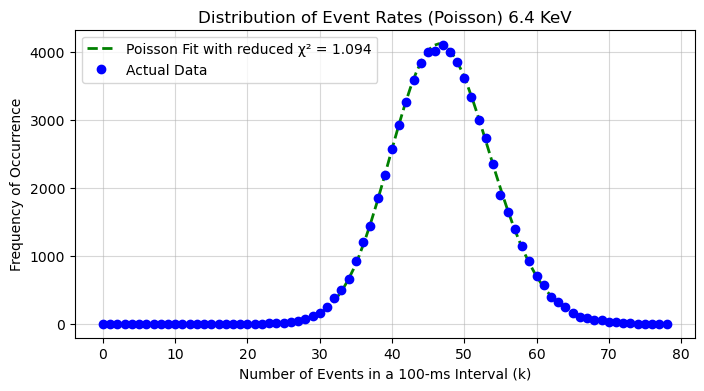

In [528]:

# 1. Convert ADU to keV
# Make sure your C1-C4 constants are defined, as well as gain and offset for your run.
energy_kev = adu_to_kev(energy)
# --- Assuming `energy_kev` is now your array of energies in keV ---
# For demonstration purposes, if your energy array is already in keV, use:

# 2. Filter for the 6.15 - 6.65 keV range
mask = (energy_kev >= 6.2) & (energy_kev <= 6.6)

# Output Array 1 & 2: Filtered energies and their corresponding times
filtered_energies = energy_kev[mask]
filtered_times_us = ts_us[mask]
# 3. Create 1 millisecond (1000 microseconds) bins

if len(ts_us) > 0:
    # We span the bins from the very beginning to the very end of the run

    # start_time = ts_us[0]
    start_time = ts_us[ts_us > 0][0]

    end_time = ts_us[-1]
    
    # Generate bin edges every 1000 us
    time_bins = np.arange(start_time, end_time + interval_us, interval_us)
    
    # Output Array 3: Calculate the frequency in each 1 ms interval
    # np.histogram counts how many 'filtered_times_us' fall into each bin
    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
    
    # (Optional) Get the corresponding timestamps for the frequencies (e.g., the start or center of the bin)
    interval_timestamps = time_bins[:-1] 
    
    print(f"Found {len(filtered_energies)} events in the 6.15 - 6.65 keV range.")
    print(f"Grouped into {len(frequencies)} 100-ms intervals.")
    print(f"Max events in a single 100-ms interval: {np.max(frequencies)}")

else:
    print("No events to process.")
    filtered_energies = np.array([])
    filtered_times_us = np.array([])
    frequencies = np.array([])
    interval_timestamps = np.array([])

#
# 1. Force integer bins (Poisson only works with discrete integers 0, 1, 2, 3...)
max_count = int(np.max(frequencies))
integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

# Calculate histogram
counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 2. Define the true Poisson Probability Mass Function
def poisson_pmf(k, lmbda):
    # Calculate probability and scale it by the total number of 1ms intervals
    total_intervals = len(frequencies)
    return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

# 3. Perform the curve fit
# A great initial guess (p0) for lambda is simply the mean of the raw data
popt, pcov = curve_fit(
    poisson_pmf, 
    bin_centers, 
    counts, 
    p0=[np.mean(frequencies)]
)
fit_lambda = popt[0]

# 4. Generate smooth X values for drawing the fit line
# (Using many points so the curve looks smooth)
fit_x = np.linspace(0, max_count, 100)

# 5. Plotting
plt.figure(figsize=(8, 4))

# Plot the fitted curve





observed = counts
expected = poisson_pmf(bin_centers, *popt)

valid_bins = expected > 0.5 
obs = observed[valid_bins]
exp = expected[valid_bins]
sigma = np.sqrt(exp)

chi_squared = np.sum(((obs - exp) / sigma) ** 2)

n_params = len(popt)  # 1 parameter (lambda)
dof = len(obs) - n_params

# 5. Calculate Reduced Chi-Squared
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared (χ²): {chi_squared:.3f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")

plt.plot(
    fit_x,
    poisson_pmf(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit with reduced χ² = {reduced_chi_squared:.3f}"
)

# Plot the actual data as points
plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Actual Data')

# Optional: log scale
# plt.yscale('log')

plt.title("Distribution of Event Rates (Poisson) 6.4 KeV")
plt.xlabel("Number of Events in a 100-ms Interval (k)")
plt.ylabel("Frequency of Occurrence")


plt.legend()
plt.grid(True, alpha=0.5)
plt.figsize = (8, 4)

# plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
plt.show()


Found 261 events in the 6.15 - 6.65 keV range.
Grouped into 70776 1-ms intervals.
Max events in a single 1-ms interval: 1


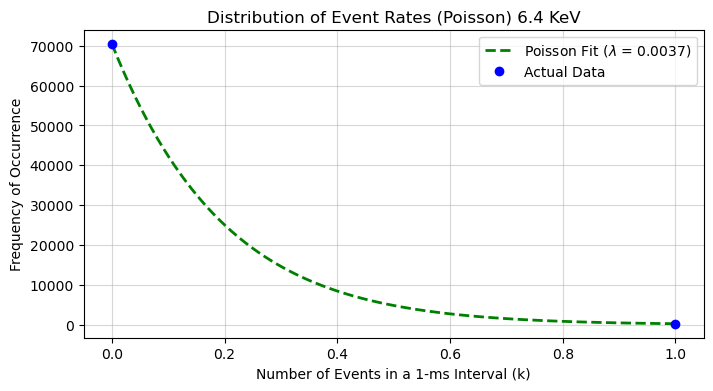

Chi-Squared (χ²): 0.000
Degrees of Freedom (dof): 1
Reduced Chi-Squared (χ²/dof): 0.000


In [529]:

# 1. Convert ADU to keV
# Make sure your C1-C4 constants are defined, as well as gain and offset for your run.
energy_kev = adu_to_kev(energy)
# --- Assuming `energy_kev` is now your array of energies in keV ---
# For demonstration purposes, if your energy array is already in keV, use:

# 2. Filter for the 6.15 - 6.65 keV range
mask = (energy_kev >= 121.8) & (energy_kev <= 122.2)

# Output Array 1 & 2: Filtered energies and their corresponding times
filtered_energies = energy_kev[mask]
filtered_times_us = ts_us[mask]
# 3. Create 1 millisecond (1000 microseconds) bins

if len(ts_us) > 0:
    # We span the bins from the very beginning to the very end of the run

    # start_time = ts_us[0]
    start_time = ts_us[ts_us > 0][0]

    end_time = ts_us[-1]
    
    # Generate bin edges every 1000 us
    time_bins = np.arange(start_time, end_time + interval_us, interval_us)
    
    # Output Array 3: Calculate the frequency in each 1 ms interval
    # np.histogram counts how many 'filtered_times_us' fall into each bin
    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
    
    # (Optional) Get the corresponding timestamps for the frequencies (e.g., the start or center of the bin)
    interval_timestamps = time_bins[:-1] 
    
    print(f"Found {len(filtered_energies)} events in the 6.15 - 6.65 keV range.")
    print(f"Grouped into {len(frequencies)} 1-ms intervals.")
    print(f"Max events in a single 1-ms interval: {np.max(frequencies)}")

else:
    print("No events to process.")
    filtered_energies = np.array([])
    filtered_times_us = np.array([])
    frequencies = np.array([])
    interval_timestamps = np.array([])

#
# 1. Force integer bins (Poisson only works with discrete integers 0, 1, 2, 3...)
max_count = int(np.max(frequencies))
integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

# Calculate histogram
counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 2. Define the true Poisson Probability Mass Function
def poisson_pmf(k, lmbda):
    # Calculate probability and scale it by the total number of 1ms intervals
    total_intervals = len(frequencies)
    return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

# 3. Perform the curve fit
# A great initial guess (p0) for lambda is simply the mean of the raw data
popt, pcov = curve_fit(
    poisson_pmf, 
    bin_centers, 
    counts, 
    p0=[np.mean(frequencies)]
)
fit_lambda = popt[0]

# 4. Generate smooth X values for drawing the fit line
# (Using many points so the curve looks smooth)
fit_x = np.linspace(0, max_count, 100)

# 5. Plotting
plt.figure(figsize=(8, 4))

# Plot the fitted curve
plt.plot(
    fit_x,
    poisson_pmf(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f})"
)

# Plot the actual data as points
plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Actual Data')

# Optional: log scale
# plt.yscale('log')

plt.title("Distribution of Event Rates (Poisson) 6.4 KeV")
plt.xlabel("Number of Events in a 1-ms Interval (k)")
plt.ylabel("Frequency of Occurrence")
plt.legend()
plt.grid(True, alpha=0.5)
# plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
plt.show()



observed = counts
expected = poisson_pmf(bin_centers, *popt)

valid_bins = expected > 0.5 
obs = observed[valid_bins]
exp = expected[valid_bins]
sigma = np.sqrt(exp)

chi_squared = np.sum(((obs - exp) / sigma) ** 2)

n_params = len(popt)  # 1 parameter (lambda)
dof = len(obs) - n_params

# 5. Calculate Reduced Chi-Squared
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared (χ²): {chi_squared:.3f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")


Found 1304587 events in the 14-14.8 keV range.
Grouped into 70776 1-ms intervals.
Max events in a single 1-ms interval: 42


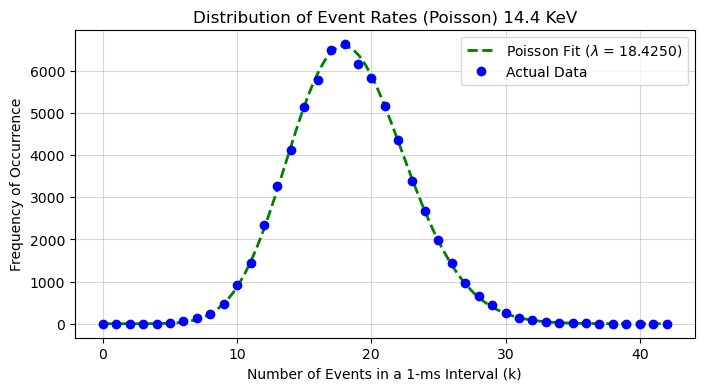

Chi-Squared (χ²): 75.056
Degrees of Freedom (dof): 36
Reduced Chi-Squared (χ²/dof): 2.085


In [530]:

# 1. Convert ADU to keV
# Make sure your C1-C4 constants are defined, as well as gain and offset for your run.
energy_kev = adu_to_kev(energy)
# --- Assuming `energy_kev` is now your array of energies in keV ---
# For demonstration purposes, if your energy array is already in keV, use:

# 2. Filter for the 14 - 14.8 keV range
mask = (energy_kev >= 14.2) & (energy_kev <= 14.6)#Todo: revert 14.9 to 14.8

# Output Array 1 & 2: Filtered energies and their corresponding times
filtered_energies = energy_kev[mask]
filtered_times_us = ts_us[mask]
# 3. Create 1 millisecond (1000 microseconds) bins

if len(ts_us) > 0:
    # We span the bins from the very beginning to the very end of the run

    # start_time = ts_us[0]
    start_time = ts_us[ts_us > 0][0]

    end_time = ts_us[-1]
    
    # Generate bin edges every 1000 us
    time_bins = np.arange(start_time, end_time + interval_us, interval_us)
    
    # Output Array 3: Calculate the frequency in each 1 ms interval
    # np.histogram counts how many 'filtered_times_us' fall into each bin
    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
    
    # (Optional) Get the corresponding timestamps for the frequencies (e.g., the start or center of the bin)
    interval_timestamps = time_bins[:-1] 
    
    print(f"Found {len(filtered_energies)} events in the 14-14.8 keV range.")
    print(f"Grouped into {len(frequencies)} 1-ms intervals.")
    print(f"Max events in a single 1-ms interval: {np.max(frequencies)}")

else:
    print("No events to process.")
    filtered_energies = np.array([])
    filtered_times_us = np.array([])
    frequencies = np.array([])
    interval_timestamps = np.array([])

#
# 1. Force integer bins (Poisson only works with discrete integers 0, 1, 2, 3...)
max_count = int(np.max(frequencies))
integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

# Calculate histogram
counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 2. Define the true Poisson Probability Mass Function
def poisson_pmf(k, lmbda):
    # Calculate probability and scale it by the total number of 1ms intervals
    total_intervals = len(frequencies)
    return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

# 3. Perform the curve fit
# A great initial guess (p0) for lambda is simply the mean of the raw data
popt, pcov = curve_fit(
    poisson_pmf, 
    bin_centers, 
    counts, 
    p0=[np.mean(frequencies)]
)
fit_lambda = popt[0]

# 4. Generate smooth X values for drawing the fit line
# (Using many points so the curve looks smooth)
fit_x = np.linspace(0, max_count, 100)

# 5. Plotting
plt.figure(figsize=(8, 4))

# Plot the fitted curve
plt.plot(
    fit_x,
    poisson_pmf(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f})"
)

# Plot the actual data as points
plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Actual Data')

# Optional: log scale
# plt.yscale('log')

plt.title("Distribution of Event Rates (Poisson) 14.4 KeV")
plt.xlabel("Number of Events in a 1-ms Interval (k)")
plt.ylabel("Frequency of Occurrence")
plt.legend()
plt.grid(True, alpha=0.5)
# plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
plt.show()



observed = counts
expected = poisson_pmf(bin_centers, *popt)

valid_bins = expected > 0.5 
obs = observed[valid_bins]
exp = expected[valid_bins]
sigma = np.sqrt(exp)

chi_squared = np.sum(((obs - exp) / sigma) ** 2)

n_params = len(popt)  # 1 parameter (lambda)
dof = len(obs) - n_params

# 5. Calculate Reduced Chi-Squared
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared (χ²): {chi_squared:.3f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")


In [582]:

times = np.asarray(ts_us, dtype=np.float64)   # seconds
adu = np.asarray(energy, dtype=np.int32)

dt = np.diff(times)
dadu = np.diff(adu)
abs_dadu = np.abs(dadu)

# Select time-spacing groups
nonzero_mask = dt > 0
zero_mask = np.isclose(dt, 0.0, atol=1e-9)



def summarize(label, mask):
    values = abs_dadu[mask]

    if values.size == 0:
        print(f"{label}: no matching pairs")
        return

    mean_abs = np.mean(values)
    max_abs = np.max(values)

    print(f"{label}")
    print(f"  Number of pairs:       {values.size}")
    print(f"  Mean absolute ΔkeV:    {adu_to_kev(mean_abs):.3f}")
    print(f"  Max absolute ΔkeV:  {adu_to_kev(max_abs):.3f}")









summarize("Δt = 0", zero_mask)
summarize("Δt > 0", nonzero_mask)


Δt = 0
  Number of pairs:       205
  Mean absolute ΔkeV:    10.887
  Max absolute ΔkeV:  117.499
Δt > 0
  Number of pairs:       9446628
  Mean absolute ΔkeV:    10.460
  Max absolute ΔkeV:  219.153


In [532]:


# def adu_to_kev(adu, gain, offset):
#     return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

# def kev_to_adu( kev, gain, offset):
#     return (kev - C4) * (C1 * gain) + C2 * gain + C3 * offset

In [533]:
# MAX_Q15 = 32767 / 32768

# dev.set_register("peak_detector", "trig_level", 0.08)
# dev.set_register("peak_detector", "n_integration", 300)

# log = EventLogger(dev)
# log.configure(
#     band_low=0.0,
#     band_high=MAX_Q15,
#     flush_ms=100,
# )

# print("trigger:", dev.get_register("peak_detector", "trig_level", raw=True))
# print("integration:", dev.get_register("peak_detector", "n_integration", raw=True))
# print("logger band:", [
#     dev.get_register("event_logger", "band_low", raw=True),
#     dev.get_register("event_logger", "band_high", raw=True),
# ])

In [534]:
# log.arm(clear=True)

# for _ in range(10):
#     print(
#         "events =", dev.get_register("event_logger", "events_lo", raw=True),
#         "ready =", dev.get_register("event_logger", "ready", raw=True),
#         "count =", dev.get_register("event_logger", "ready_count", raw=True),
#         "peak =", dev.get_register("peak_detector", "peak_max_out", raw=True),
#     )
#     time.sleep(0.2)

# log.disarm()

In [535]:
# n = log.run(duration=5, output_dir="run2")
# print("drained events:", n)
# print("dropped:", log.dropped())

In [536]:
# log.arm(clear=True)

# # Signal chain
# dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)

# for idx in range(9):
#     dev.set_register("fir9", f"h{idx}", 0.109375)


# # Peak detector
# dev.set_register("peak_detector", "trig_level", 0.008, raw=True)
# # dev.set_register("peak_detector", "fall_level", 1, raw=True)
# # dev.set_register("peak_detector", "base_return", 0, raw=True)
# # dev.set_register("peak_detector", "dead_time", 1000, raw=True)

# # Use 0 for positive-going pulses, 1 for negative-going pulses
# dev.set_register("peak_detector", "invert_input", 0, raw=True)


# dev.set_register("peak_detector", "n_integration", 300)

# # Histogram
# dev.set_register("histogram", "offset", -0.007165694774164504)
# dev.set_register("histogram", "gain", 0.08361136196556104)

# dev.set_register("histogram", "pulse_width", 1024)
# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)
# dev.set_register("histogram", "counting_enable", 1)
# # dev.set_register("histogram", "band_low", 0.0)
# # dev.set_register("histogram", "band_high", MAX_Q15)

# log = EventLogger(dev)
# log.configure(flush_ms=100)
# # log. /configure(flush_ms=100)

# log.run(duration=5, output_dir=f"{runfile}")

# log.disarm()

In [537]:

# RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
# dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
# dev.base.load_bitfile()

# # Signal chain
# dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)
# dev.set_register('fir9', 'h0', 0.99)

# # Peak detector
# dev.set_register("peak_detector", "invert_input", 0)
# dev.set_register("peak_detector", "trig_level", 0.01)
# dev.set_register("peak_detector", "integration_mode", 0)
# dev.set_register("peak_detector", "n_integration", 1000)

# # Histogram
# dev.set_register("histogram", "offset", 0)
# dev.set_register("histogram", "gain", 0.1)
# dev.set_register("histogram", "band_low", 0.03)
# dev.set_register("histogram", "band_high", 0.35)
# dev.set_register("histogram", "pulse_width", 1024)
# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)

# log = EventLogger(dev)
# log.configure(flush_ms=100)
# log.run(duration=6, output_dir="run1")

In [538]:
# histogram = dev.read_sequential_axi_data("histogram", "read_address", "read_data", 0, 1023)
# plt.plot(histogram)

In [539]:
# dev.get_all_registers("histogram")
# # offset

Found 1304587 events in the 14-14.8 keV range.
Grouped into 70776 1-s intervals.
Max events in a single 1-s interval: 42


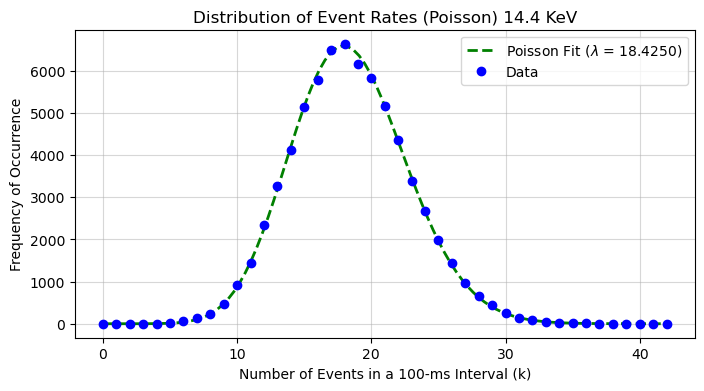

Chi-Squared (χ²): 75.056
Degrees of Freedom (dof): 36
Reduced Chi-Squared (χ²/dof): 2.085


In [540]:

# 1. Convert ADU to keV
# Make sure your C1-C4 constants are defined, as well as gain and offset for your run.
energy_kev = adu_to_kev(energy)
# --- Assuming `energy_kev` is now your array of energies in keV ---
# For demonstration purposes, if your energy array is already in keV, use:

# 2. Filter for the 14 - 14.8 keV range
mask = (energy_kev >= 14.2) & (energy_kev <= 14.6)#Todo: revert 14.9 to 14.8

# Output Array 1 & 2: Filtered energies and their corresponding times
filtered_energies = energy_kev[mask]
filtered_times_us = ts_us[mask]
# 3. Create 1 millisecond (1000 microseconds) bins

if len(ts_us) > 0:
    # We span the bins from the very beginning to the very end of the run

    # start_time = ts_us[0]
    start_time = ts_us[ts_us > 0][0]

    end_time = ts_us[-1]
    
    # Generate bin edges every 1000 us
    time_bins = np.arange(start_time, end_time + interval_us, interval_us)
    
    # Output Array 3: Calculate the frequency in each 1 ms interval
    # np.histogram counts how many 'filtered_times_us' fall into each bin
    frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
    
    # (Optional) Get the corresponding timestamps for the frequencies (e.g., the start or center of the bin)
    interval_timestamps = time_bins[:-1] 
    
    print(f"Found {len(filtered_energies)} events in the 14-14.8 keV range.")
    print(f"Grouped into {len(frequencies)} 1-s intervals.")
    print(f"Max events in a single 1-s interval: {np.max(frequencies)}")

else:
    print("No events to process.")
    filtered_energies = np.array([])
    filtered_times_us = np.array([])
    frequencies = np.array([])
    interval_timestamps = np.array([])

#
# 1. Force integer bins (Poisson only works with discrete integers 0, 1, 2, 3...)
max_count = int(np.max(frequencies))
integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

# Calculate histogram
counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 2. Define the true Poisson Probability Mass Function
def poisson_pmf(k, lmbda):
    # Calculate probability and scale it by the total number of 1ms intervals
    total_intervals = len(frequencies)
    return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

# 3. Perform the curve fit
# A great initial guess (p0) for lambda is simply the mean of the raw data
popt, pcov = curve_fit(
    poisson_pmf, 
    bin_centers, 
    counts, 
    p0=[np.mean(frequencies)]
)
fit_lambda = popt[0]

# 4. Generate smooth X values for drawing the fit line
# (Using many points so the curve looks smooth)
fit_x = np.linspace(0, max_count, 100)

# 5. Plotting
plt.figure(figsize=(8, 4))

# Plot the fitted curve
plt.plot(
    fit_x,
    poisson_pmf(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f})"
)

# Plot the actual data as points
plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Data')

# Optional: log scale
# plt.yscale('log')

plt.title("Distribution of Event Rates (Poisson) 14.4 KeV")
plt.xlabel("Number of Events in a 100-ms Interval (k)")
plt.ylabel("Frequency of Occurrence")
plt.legend()
plt.grid(True, alpha=0.5)
# plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
plt.show()



observed = counts
expected = poisson_pmf(bin_centers, *popt)

valid_bins = expected > 0.5 
obs = observed[valid_bins]
exp = expected[valid_bins]
sigma = np.sqrt(exp)

chi_squared = np.sum(((obs - exp) / sigma) ** 2)

n_params = len(popt)  # 1 parameter (lambda)
dof = len(obs) - n_params

# 5. Calculate Reduced Chi-Squared
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared (χ²): {chi_squared:.3f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")


In [541]:
total_time = 10  # seconds
sampling_rate = 100000  # Hz

noise = np.random.normal(scale=1, size=int(total_time * sampling_rate)  )
frequency = 1000  # Frequency of the sine wave in Hz
axion = 0.1*np.sin(np.linspace(0, 20, int(total_time * sampling_rate))*2*np.pi*frequency)
axion2 = 0.2*np.sin(np.linspace(0, 20, int(total_time * sampling_rate))*2*np.pi*frequency*3)

measurement = axion + axion2 + noise
t = np.linspace(0, total_time, int(total_time * sampling_rate))
plt.plot(t, measurement)
# plt.plot(t, axion, color='orange', label='Axion Signal')
# plt.plot(t, axion2, color='green', label='Axion Signal 2')
# plt.xlim(0.1,0.101)


In [542]:
import scipy.signal as signal
f, psd_noise = signal.welch(noise, fs=sampling_rate, nperseg = len(measurement)//8)
f, psd = signal.welch(measurement, fs=sampling_rate, nperseg = len(measurement)//8)


plt.plot(f, psd)
#plt.plot(f, psd_noise)

Found 1304587 events in the 14.2 - 14.6 keV range.
Grouped into 109 100.0-ms intervals.
Max events in a single 100.0-ms interval: 12251
Chi-Squared (χ²): 0.000
Degrees of Freedom (dof): -1
Reduced Chi-Squared (χ²/dof): -0.000
Fitted Lambda (λ): 11968.688


/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_40830/3398250839.py:48: RuntimeWarning: overflow encountered in power
  return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )
/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_40830/3398250839.py:48: RuntimeWarning: invalid value encountered in multiply
  return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )
/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_40830/3398250839.py:52: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


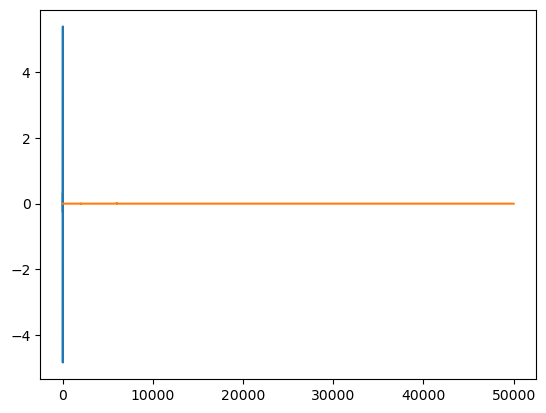

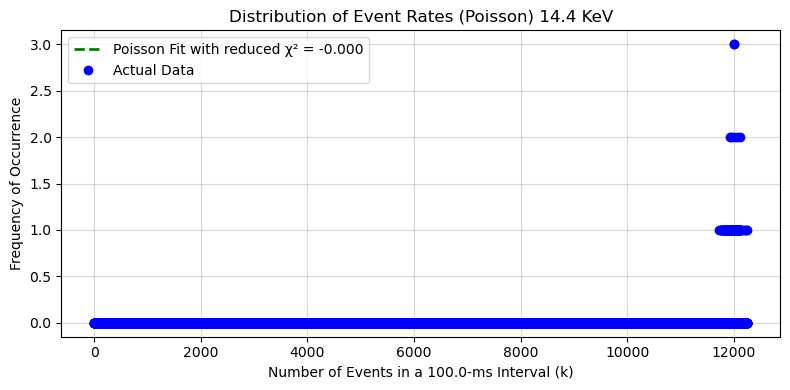

Found 3326124 events in the 6.2 - 6.6 keV range.
Grouped into 149 40.0-ms intervals.
Max events in a single 40.0-ms interval: 22737
Chi-Squared (χ²): 0.000
Degrees of Freedom (dof): -1
Reduced Chi-Squared (χ²/dof): -0.000
Fitted Lambda (λ): 22322.980


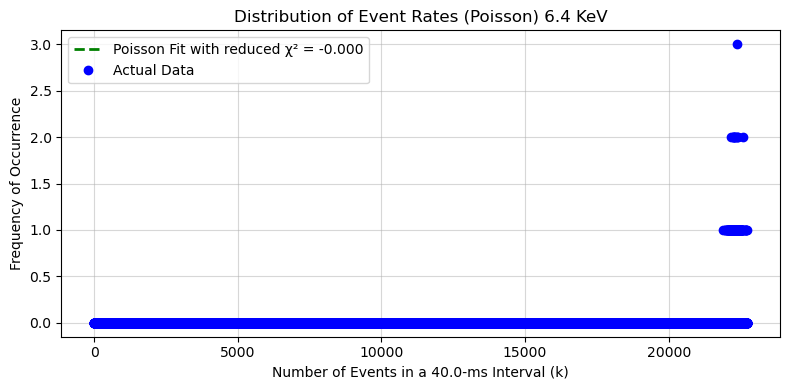

Found 261 events in the 121.8 - 122.2 keV range.
Grouped into 7 5000.0-ms intervals.
Max events in a single 5000.0-ms interval: 43
Chi-Squared (χ²): 0.000
Degrees of Freedom (dof): -1
Reduced Chi-Squared (χ²/dof): -0.000
Fitted Lambda (λ): 39.170


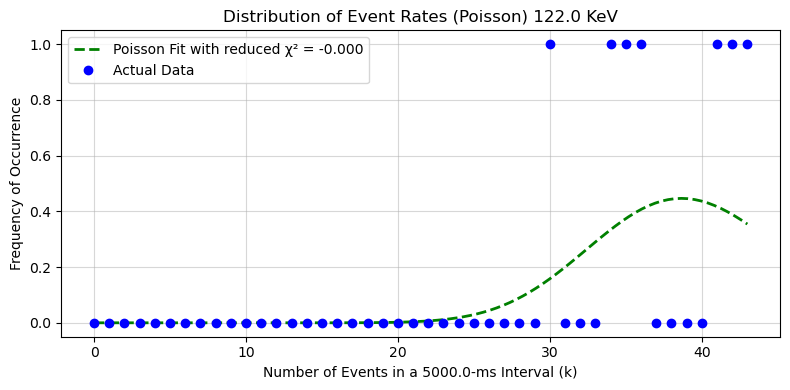

In [543]:
def graph_poissonian(e_start=14.2, e_end=14.6, auto_bin = True, bin=100000, save=False):
    energy_kev = adu_to_kev(energy)
    # --- Assuming `energy_kev` is now your array of energies in keV ---
    # For demonstration purposes, if your energy array is already in keV, use:

    # 2. Filter for the 14.2 - 14.6 keV range
    mask = (energy_kev >= e_start) & (energy_kev <= e_end)

    # Output Array 1 & 2: Filtered energies and their corresponding times
    filtered_energies = energy_kev[mask]
    filtered_times_us = ts_us[mask]

    if len(ts_us) > 0:

        start_time = ts_us[ts_us > 0][0]

        end_time = ts_us[-1]
        
        time_bins = np.arange(start_time, end_time + interval_us, bin) 
      
        frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)
        if auto_bin:
            frequencies, time_bins = np.histogram(filtered_times_us, bins="scott")
        interval_timestamps = time_bins[:-1] 
        
        print(f"Found {len(filtered_energies)} events in the {e_start} - {e_end} keV range.")
        print(f"Grouped into {len(frequencies)} {bin/(1e3)}-ms intervals.")
        print(f"Max events in a single {bin/(1e3)}-ms interval: {np.max(frequencies)}")

    else:
        print("No events to process.")
        filtered_energies = np.array([])
        filtered_times_us = np.array([])
        frequencies = np.array([])
        interval_timestamps = np.array([])

    max_count = int(np.max(frequencies))
    integer_bins = np.arange(-0.5, max_count + 1.5, 1.0)

    # Calculate histogram
    counts, bin_edges = np.histogram(frequencies, bins=integer_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 2. Define the true Poisson Probability Mass Function
    def poisson_pmf(k, lmbda):
        # Calculate probability and scale it by the total number of 1ms intervals
        total_intervals = len(frequencies)
        return total_intervals * ( (lmbda**k * np.exp(-lmbda)) / factorial(k) )

    # 3. Perform the curve fit
    # A great initial guess (p0) for lambda is simply the mean of the raw data
    popt, pcov = curve_fit(
        poisson_pmf, 
        bin_centers, 
        counts, 
        p0=[np.mean(frequencies)]
    )
    fit_lambda = popt[0]

    fit_x = np.linspace(0, max_count, 100)

    # 5. Plotting
    plt.figure(figsize=(8, 4))

    observed = counts
    expected = poisson_pmf(bin_centers, *popt)

    valid_bins = expected > 0.5 
    obs = observed[valid_bins]
    exp = expected[valid_bins]
    sigma = np.sqrt(exp)

    chi_squared = np.sum(((obs - exp) / sigma) ** 2)

    n_params = len(popt)  # 1 parameter (lambda)
    dof = len(obs) - n_params

    # 5. Calculate Reduced Chi-Squared
    reduced_chi_squared = chi_squared / dof

    print(f"Chi-Squared (χ²): {chi_squared:.3f}")
    print(f"Degrees of Freedom (dof): {dof}")
    print(f"Reduced Chi-Squared (χ²/dof): {reduced_chi_squared:.3f}")
    print(f"Fitted Lambda (λ): {fit_lambda:.3f}")


    plt.plot(
        fit_x,
        poisson_pmf(fit_x, *popt),
        "g--",
        linewidth=2,
        label=f"Poisson Fit with reduced χ² = {reduced_chi_squared:.3f}"
    )

    # Plot the actual data as points
    plt.plot(bin_centers, counts, marker='o', linestyle='', color='blue', label='Actual Data')

    # Optional: log scale
    # plt.yscale('log')
    average_kev = np.average([e_end,e_start])
    plt.title(f"Distribution of Event Rates (Poisson) {average_kev:.1f} KeV")
    plt.xlabel(f"Number of Events in a {bin/(1e3)}-ms Interval (k)")
    plt.ylabel("Frequency of Occurrence")


    plt.legend()
    plt.grid(True, alpha=0.5)
    # plt.ylim(0,20)  # Adjust y-limit to ensure all data is visible
    plt.tight_layout()


    if save:
        # Define your desired output path
        base_path = Path(f"poisson_fit_{average_kev:.1f}.png")
        stem = base_path.stem  # "poisson_fit"
        suffix = base_path.suffix  # ".png"
        parent = base_path.parent  # Folder directory

        save_path = base_path
        counter = 1

        # Increment counter until a unique filename is found
        while save_path.exists():
            save_path = parent / f"{stem}_{counter}{suffix}"
            counter += 1
        plt.savefig(save_path, transparent=True, bbox_inches='tight')
        print(f"Saved figure to: {save_path}")

    plt.show()


graph_poissonian(e_start=14.2, e_end=14.6,auto_bin=True, bin=100000, save=False)
graph_poissonian(e_start=6.2, e_end=6.6, auto_bin=True, bin=40000, save=False)
graph_poissonian(e_start=121.8, e_end=122.2, auto_bin=True, bin=5000000, save=False)